# CSE425 — Multi-Genre Music Generation
## Steps 3 & 4: Preprocessing + PyTorch Dataset / DataLoader

>


## Cell 0

In [3]:
import os

MAESTRO_URL = "https://storage.googleapis.com/magentadata/datasets/maestro/v3.0.0/maestro-v3.0.0-midi.zip"
DATA_DIR    = "/content/maestro"
ZIP_PATH    = "/content/maestro-v3.0.0-midi.zip"
CSV_PATH    = os.path.join(DATA_DIR, "maestro-v3.0.0.csv")

if not os.path.exists(CSV_PATH):
    print("Downloading MAESTRO MIDI dataset (~57 MB) …")
    !wget -q --show-progress -O {ZIP_PATH} {MAESTRO_URL}
    !unzip -q {ZIP_PATH} -d /content/
    !mv /content/maestro-v3.0.0 {DATA_DIR} 2>/dev/null || true
    print("Done.")
else:
    print("Dataset already present — skipping download.")

Dataset already present — skipping download.


---
## Cell 1 — Install Libraries & Imports

In [4]:
!pip install pretty_midi miditok --quiet

import os, json, random, pickle
import numpy as np
import pandas as pd
import pretty_midi
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from pathlib import Path
from tqdm.auto import tqdm

print(f"PyTorch  : {torch.__version__}")
print(f"GPU      : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only'}")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

PyTorch  : 2.10.0+cpu
GPU      : CPU only



## Cell 2 — Global Configuration



In [5]:
# Paths
DATA_DIR        = "/content/maestro"
CSV_PATH        = os.path.join(DATA_DIR, "maestro-v3.0.0.csv")
PROCESSED_DIR   = "/content/processed"
os.makedirs(PROCESSED_DIR, exist_ok=True)

#Piano-Roll settings (Tasks 1 & 2)
FS              = 16
WINDOW_LEN      = 128
MIN_ACTIVE_FRAC = 0.02
PIANO_LOW       = 21
PIANO_HIGH      = 109
N_PITCHES       = PIANO_HIGH - PIANO_LOW

# Token-Sequence settings (Tasks 3 & 4)
MAX_SEQ_LEN     = 512
VELOCITY_BINS   = 32

# DataLoader settings
BATCH_SIZE      = 64
NUM_WORKERS     = 2
MAX_FILES       = 50

print("Configuration loaded.")
print(f"  Piano-roll  : {N_PITCHES} pitches × {WINDOW_LEN} frames   ({WINDOW_LEN/FS:.0f}s windows)")
print(f"  Token seq   : max {MAX_SEQ_LEN} tokens per sample")
print(f"  MAX_FILES   : {MAX_FILES}  (set to None to use full dataset)")

Configuration loaded.
  Piano-roll  : 88 pitches × 128 frames   (8s windows)
  Token seq   : max 512 tokens per sample
  MAX_FILES   : 50  (set to None to use full dataset)



## Cell 3 — Load Metadata & Build File Lists

In [6]:
meta = pd.read_csv(CSV_PATH)
meta['filepath'] = meta['midi_filename'].apply(lambda p: os.path.join(DATA_DIR, p))

# Use the predefined split
train_meta = meta[meta['split'] == 'train'].reset_index(drop=True)
val_meta   = meta[meta['split'] == 'validation'].reset_index(drop=True)
test_meta  = meta[meta['split'] == 'test'].reset_index(drop=True)

if MAX_FILES is not None:
    train_meta = train_meta.head(MAX_FILES)
    val_meta   = val_meta.head(max(10, MAX_FILES // 8))
    test_meta  = test_meta.head(max(10, MAX_FILES // 8))

print(f"Files to process → train: {len(train_meta)}  val: {len(val_meta)}  test: {len(test_meta)}")

Files to process → train: 50  val: 10  test: 10



# STEP 3 — Preprocessing



## 3A. Piano-Roll Pipeline (Tasks 1 & 2)

**Four stages per file:**
1. Extract piano-roll with `get_piano_roll(fs=FS)` → shape `(128, T)`, slice rows 21–108 → `(88, T)`, transpose → `(T, 88)`
2. Binarize (set every non-zero cell to 1)
3. Segment into non-overlapping windows of length 128
4. Filter: discard windows where fewer than 2 % of cells are active

In [7]:
def midi_to_piano_roll_windows(filepath, fs=FS, window_len=WINDOW_LEN,min_active_frac=MIN_ACTIVE_FRAC):

    try:
        pm   = pretty_midi.PrettyMIDI(filepath)
        roll = pm.get_piano_roll(fs=fs)          # (128, T)  float32
        roll = roll[PIANO_LOW:PIANO_HIGH, :]      # (88,  T)
        roll = roll.T                             # (T,  88)

        # Stage 2 — binarize
        roll = (roll > 0).astype(np.uint8)

        # Stage 3 — segment into non-overlapping windows
        T       = roll.shape[0]
        n_full  = T // window_len
        if n_full == 0:
            return np.empty((0, window_len, N_PITCHES), dtype=np.uint8)
        roll    = roll[:n_full * window_len]      # trim tail
        windows = roll.reshape(n_full, window_len, N_PITCHES)   # (N, 128, 88)

        # Stage 4 — filter sparse windows
        active_frac = windows.mean(axis=(1, 2))   # fraction of 1s per window
        windows     = windows[active_frac >= min_active_frac]

        return windows

    except Exception:
        return np.empty((0, window_len, N_PITCHES), dtype=np.uint8)

In [8]:
# Quick sanity check on a single file before bulk processing
sample_path = train_meta['filepath'].iloc[0]
sample_wins = midi_to_piano_roll_windows(sample_path)
print(f"Sample file : {os.path.basename(sample_path)}")
print(f"Windows extracted (after sparse filter) : {len(sample_wins)}")
print(f"Window shape  : {sample_wins.shape}   (N × T × 88)")
if len(sample_wins) > 0:
    print(f"Active-cell fraction in window 0 : {sample_wins[0].mean()*100:.2f}%")

Sample file : MIDI-Unprocessed_Chamber3_MID--AUDIO_10_R3_2018_wav--1.midi
Windows extracted (after sparse filter) : 87
Window shape  : (87, 128, 88)   (N × T × 88)
Active-cell fraction in window 0 : 4.02%


In [9]:
def build_piano_roll_dataset(df, split_name, save_dir=PROCESSED_DIR):

    save_path = os.path.join(save_dir, f"piano_roll_{split_name}.npy")

    if os.path.exists(save_path):
        print(f"[{split_name}] Loading cached piano-roll from {save_path}")
        return np.load(save_path)

    all_windows   = []
    skipped       = 0
    total_windows = 0

    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"Piano-roll [{split_name}]"):
        wins = midi_to_piano_roll_windows(row['filepath'])
        if len(wins) == 0:
            skipped += 1
            continue
        all_windows.append(wins)
        total_windows += len(wins)

    if total_windows == 0:
        print(f"[{split_name}] WARNING: No windows extracted.")
        return np.empty((0, WINDOW_LEN, N_PITCHES), dtype=np.uint8)

    all_windows = np.concatenate(all_windows, axis=0)   # (N_total, 128, 88)
    np.save(save_path, all_windows)

    print(f"[{split_name}] Files: {len(df)-skipped} ok / {skipped} skipped")
    print(f"[{split_name}] Total windows: {total_windows:,}  shape: {all_windows.shape}")
    print(f"[{split_name}] Saved → {save_path}")
    return all_windows

In [10]:
# ── Build and save piano-roll arrays for all three splits ───────────────────
pr_train = build_piano_roll_dataset(train_meta, 'train')
pr_val   = build_piano_roll_dataset(val_meta,   'validation')
pr_test  = build_piano_roll_dataset(test_meta,  'test')

print(f"\nFinal sizes → train: {pr_train.shape}  val: {pr_val.shape}  test: {pr_test.shape}")
print(f"Disk usage  → train: {pr_train.nbytes/1e6:.1f} MB")

Piano-roll [train]:   0%|          | 0/50 [00:00<?, ?it/s]

[train] Files: 50 ok / 0 skipped
[train] Total windows: 3,435  shape: (3435, 128, 88)
[train] Saved → /content/processed/piano_roll_train.npy


Piano-roll [validation]:   0%|          | 0/10 [00:00<?, ?it/s]

[validation] Files: 10 ok / 0 skipped
[validation] Total windows: 677  shape: (677, 128, 88)
[validation] Saved → /content/processed/piano_roll_validation.npy


Piano-roll [test]:   0%|          | 0/10 [00:00<?, ?it/s]

[test] Files: 10 ok / 0 skipped
[test] Total windows: 452  shape: (452, 128, 88)
[test] Saved → /content/processed/piano_roll_test.npy

Final sizes → train: (3435, 128, 88)  val: (677, 128, 88)  test: (452, 128, 88)
Disk usage  → train: 38.7 MB


### Verify a few windows visually

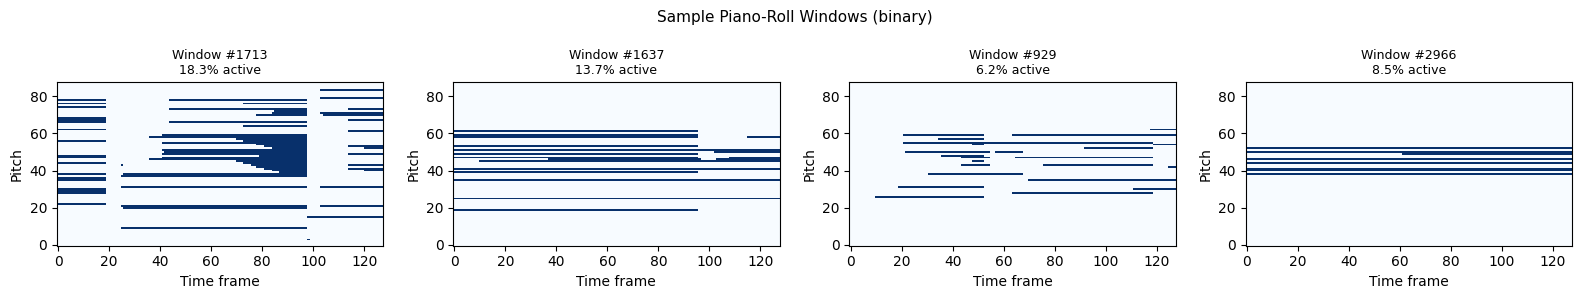

In [11]:
if len(pr_train) > 0:
    fig, axes = plt.subplots(1, 4, figsize=(16, 3))
    idx_list  = np.random.choice(len(pr_train), 4, replace=False)
    for ax, idx in zip(axes, idx_list):
        ax.imshow(pr_train[idx].T, aspect='auto', origin='lower',
                  cmap='Blues', interpolation='nearest')
        active = pr_train[idx].mean() * 100
        ax.set_title(f"Window #{idx}\n{active:.1f}% active", fontsize=9)
        ax.set_xlabel('Time frame')
        ax.set_ylabel('Pitch')
    plt.suptitle('Sample Piano-Roll Windows (binary)', fontsize=11)
    plt.tight_layout()
    plt.savefig('/content/processed/sample_piano_roll_windows.png', dpi=120)
    plt.show()


## 3B. Token Sequence Pipeline (Tasks 3 & 4)

We use `miditok`'s **REMI** tokeniser.  
REMI events: `Bar`, `Position`, `Pitch`, `Velocity`, `Duration`.  
Each file becomes a flat list of integer IDs.



In [12]:
from miditok import REMI, TokenizerConfig

TOKENIZER_PATH = os.path.join(PROCESSED_DIR, 'remi_tokenizer.json')

config = TokenizerConfig(
    num_velocities   = VELOCITY_BINS,
    use_chords       = False,    # keep it simple for now
    use_rests        = True,
    use_tempos       = True,
    use_time_signatures = True,
)
tokenizer = REMI(config)

VOCAB_SIZE = len(tokenizer)
print(f"REMI vocabulary size : {VOCAB_SIZE} tokens")
print(f"Special tokens       : {tokenizer.special_tokens}")

REMI vocabulary size : 421 tokens
Special tokens       : ['PAD_None', 'BOS_None', 'EOS_None', 'MASK_None']


In [13]:
# Test tokenisation on one file
sample_path = train_meta['filepath'].iloc[0]
sample_tokens = tokenizer(sample_path)
sample_ids    = sample_tokens[0].ids

print(f"File         : {os.path.basename(sample_path)}")
print(f"Token count  : {len(sample_ids)}")
print(f"First 20 IDs : {sample_ids[:20]}")

# Decode back to event names for inspection
sample_events = sample_tokens[0].tokens[:20]
print(f"First 20 events: {sample_events}")

File         : MIDI-Unprocessed_Chamber3_MID--AUDIO_10_R3_2018_wav--1.midi
Token count  : 15992
First 20 IDs : [4, 420, 190, 392, 359, 206, 51, 106, 138, 219, 56, 110, 127, 350, 192, 62, 110, 148, 55, 105]
First 20 events: ['Bar_None', 'TimeSig_4/4', 'Position_0', 'Tempo_121.29', 'Rest_2.0.2', 'Position_16', 'Pitch_67', 'Velocity_51', 'Duration_1.5.8', 'Position_29', 'Pitch_72', 'Velocity_67', 'Duration_0.2.8', 'Rest_0.3.8', 'Position_2', 'Pitch_78', 'Velocity_67', 'Duration_2.7.8', 'Pitch_71', 'Velocity_47']


In [14]:
def build_token_dataset(df, split_name, tokenizer, max_seq_len=MAX_SEQ_LEN,save_dir=PROCESSED_DIR):

    save_path = os.path.join(save_dir, f"tokens_{split_name}.pkl")

    if os.path.exists(save_path):
        print(f"[{split_name}] Loading cached token sequences from {save_path}")
        with open(save_path, 'rb') as f:
            return pickle.load(f)

    sequences = []
    skipped   = 0

    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"Tokenise [{split_name}]"):
        try:
            tok_seq = tokenizer(row['filepath'])  # returns list of TokSequence
            ids     = tok_seq[0].ids              # [0] = first (only) track

            # Chunk into max_seq_len pieces (need at least 2 tokens for input/target)
            for start in range(0, len(ids) - 1, max_seq_len):
                chunk = ids[start : start + max_seq_len + 1]  # +1 so we can shift
                if len(chunk) < 2:
                    continue
                sequences.append(chunk)

        except Exception:
            skipped += 1

    with open(save_path, 'wb') as f:
        pickle.dump(sequences, f)

    print(f"[{split_name}] Files skipped : {skipped}")
    print(f"[{split_name}] Total chunks  : {len(sequences):,}")
    print(f"[{split_name}] Saved → {save_path}")
    return sequences

In [15]:
# Build and save token datasets for all splits
tok_train = build_token_dataset(train_meta, 'train',      tokenizer)
tok_val   = build_token_dataset(val_meta,   'validation', tokenizer)
tok_test  = build_token_dataset(test_meta,  'test',       tokenizer)

print(f"\nToken chunks → train: {len(tok_train):,}  val: {len(tok_val):,}  test: {len(tok_test):,}")
print(f"Example chunk length : {len(tok_train[0])} tokens")

Tokenise [train]:   0%|          | 0/50 [00:00<?, ?it/s]

[train] Files skipped : 0
[train] Total chunks  : 2,067
[train] Saved → /content/processed/tokens_train.pkl


Tokenise [validation]:   0%|          | 0/10 [00:00<?, ?it/s]

[validation] Files skipped : 0
[validation] Total chunks  : 349
[validation] Saved → /content/processed/tokens_validation.pkl


Tokenise [test]:   0%|          | 0/10 [00:00<?, ?it/s]

[test] Files skipped : 0
[test] Total chunks  : 248
[test] Saved → /content/processed/tokens_test.pkl

Token chunks → train: 2,067  val: 349  test: 248
Example chunk length : 513 tokens


Sequence length → min: 9  max: 513  mean: 507


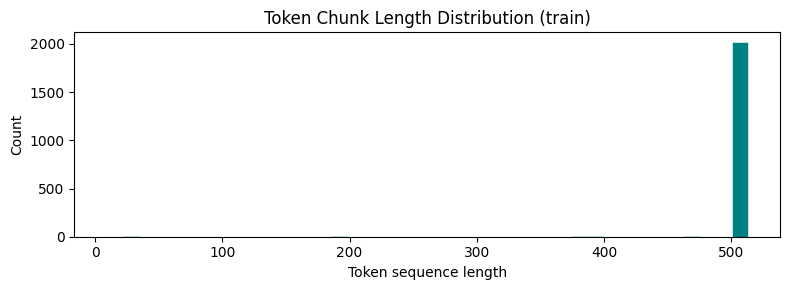

In [16]:
# Token sequence length distribution (diagnostic)
print(f"Sequence length → min: {min(lengths)}  max: {max(lengths)}  mean: {np.mean(lengths):.0f}")

plt.figure(figsize=(8, 3))
plt.hist(lengths, bins=40, color='teal', edgecolor='white', linewidth=0.4)
plt.xlabel('Token sequence length')
plt.ylabel('Count')
plt.title('Token Chunk Length Distribution (train)')
plt.tight_layout()
plt.savefig('/content/processed/token_length_distribution.png', dpi=120)
plt.show()


# STEP 4 — PyTorch Dataset & DataLoader


## 4A. PianoRollDataset (Tasks 1 & 2)

In [17]:
class PianoRollDataset(Dataset):

    def __init__(self, windows: np.ndarray):

        self.data = torch.from_numpy(windows.astype(np.float32))
        print(f"PianoRollDataset: {len(self.data):,} windows  "
              f"shape per sample: {tuple(self.data[0].shape)}")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # Returns shape (window_len, 88)
        return self.data[idx]

In [18]:
# Instantiate piano-roll datasets
pr_dataset_train = PianoRollDataset(pr_train)
pr_dataset_val   = PianoRollDataset(pr_val)
pr_dataset_test  = PianoRollDataset(pr_test)

PianoRollDataset: 3,435 windows  shape per sample: (128, 88)
PianoRollDataset: 677 windows  shape per sample: (128, 88)
PianoRollDataset: 452 windows  shape per sample: (128, 88)


In [19]:
# Create DataLoaders
pr_loader_train = DataLoader(
    pr_dataset_train,
    batch_size  = BATCH_SIZE,
    shuffle     = True,          # shuffle every epoch for training
    num_workers = NUM_WORKERS,
    pin_memory  = torch.cuda.is_available(),
    drop_last   = True,          # keep all batches the same size
)

pr_loader_val = DataLoader(
    pr_dataset_val,
    batch_size  = BATCH_SIZE,
    shuffle     = False,         # never shuffle validation / test
    num_workers = NUM_WORKERS,
    pin_memory  = torch.cuda.is_available(),
)

pr_loader_test = DataLoader(
    pr_dataset_test,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = NUM_WORKERS,
    pin_memory  = torch.cuda.is_available(),
)

# Sanity check
sample_batch = next(iter(pr_loader_train))
print(f"PianoRoll batch shape : {sample_batch.shape}   (batch × time × pitch)")
print(f"dtype                 : {sample_batch.dtype}")
print(f"value range           : [{sample_batch.min().item():.0f}, {sample_batch.max().item():.0f}]")
print(f"\nTrain batches per epoch : {len(pr_loader_train)}")
print(f"Val   batches per epoch : {len(pr_loader_val)}")

PianoRoll batch shape : torch.Size([64, 128, 88])   (batch × time × pitch)
dtype                 : torch.float32
value range           : [0, 1]

Train batches per epoch : 53
Val   batches per epoch : 11



## 4B. TokenDataset (Tasks 3 & 4)



In [20]:
# Retrieve the PAD token id from the tokeniser
PAD_ID = tokenizer['PAD_None']
print(f"PAD token id : {PAD_ID}")

PAD token id : 0


In [21]:
class TokenDataset(Dataset):

    def __init__(self, sequences):

        self.sequences = sequences
        print(f"TokenDataset: {len(sequences):,} sequences")

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        ids        = torch.tensor(self.sequences[idx], dtype=torch.long)
        input_ids  = ids[:-1]   # x₁ … x_{T-1}
        target_ids = ids[1:]    # x₂ … x_T
        return input_ids, target_ids

In [22]:
def token_collate_fn(batch):
    input_list, target_list = zip(*batch)

    # pad_sequence pads along dim=0 (sequence length), then we transpose to (B, T)
    input_padded  = pad_sequence(input_list,  batch_first=True, padding_value=PAD_ID)
    target_padded = pad_sequence(target_list, batch_first=True, padding_value=PAD_ID)

    # Attention mask: 1 where real token, 0 at pad position
    attn_mask = (input_padded != PAD_ID)

    return input_padded, target_padded, attn_mask

In [23]:
#  Instantiate token datasets
tok_dataset_train = TokenDataset(tok_train)
tok_dataset_val   = TokenDataset(tok_val)
tok_dataset_test  = TokenDataset(tok_test)

TokenDataset: 2,067 sequences
TokenDataset: 349 sequences
TokenDataset: 248 sequences


In [24]:
#  Create DataLoaders
tok_loader_train = DataLoader(
    tok_dataset_train,
    batch_size   = BATCH_SIZE,
    shuffle      = True,
    num_workers  = NUM_WORKERS,
    pin_memory   = torch.cuda.is_available(),
    collate_fn   = token_collate_fn,
    drop_last    = True,
)

tok_loader_val = DataLoader(
    tok_dataset_val,
    batch_size   = BATCH_SIZE,
    shuffle      = False,
    num_workers  = NUM_WORKERS,
    pin_memory   = torch.cuda.is_available(),
    collate_fn   = token_collate_fn,
)

tok_loader_test = DataLoader(
    tok_dataset_test,
    batch_size   = BATCH_SIZE,
    shuffle      = False,
    num_workers  = NUM_WORKERS,
    pin_memory   = torch.cuda.is_available(),
    collate_fn   = token_collate_fn,
)

#Sanity check
inp, tgt, mask = next(iter(tok_loader_train))
print(f"Token batch shapes:")
print(f"  input_ids  : {inp.shape}   dtype={inp.dtype}")
print(f"  target_ids : {tgt.shape}   dtype={tgt.dtype}")
print(f"  attn_mask  : {mask.shape}  dtype={mask.dtype}")
print(f"\nPad fraction in batch : {(inp == PAD_ID).float().mean()*100:.1f}%")
print(f"\nTrain token batches per epoch : {len(tok_loader_train)}")

Token batch shapes:
  input_ids  : torch.Size([64, 512])   dtype=torch.int64
  target_ids : torch.Size([64, 512])   dtype=torch.int64
  attn_mask  : torch.Size([64, 512])  dtype=torch.bool

Pad fraction in batch : 1.2%

Train token batches per epoch : 32



## 4C. Verify Input- Target Alignment




In [25]:
# Take the first real (non-padded) sequence in the batch
seq_len     = mask[0].sum().item()   # number of real tokens
inp_sample  = inp[0, :seq_len].tolist()
tgt_sample  = tgt[0, :seq_len].tolist()

print("Input  (x₁ … x_T-1) :", inp_sample[:8], "…")
print("Target (x₂ … x_T)   :", tgt_sample[:8], "…")
print()

# They should be shifted by exactly 1 position
assert inp_sample[1:6] == tgt_sample[0:5], "Shift mismatch — check TokenDataset!"
print("✓ Input/Target shift is correct.")

Input  (x₁ … x_T-1) : [110, 127, 54, 115, 126, 43, 112, 126] …
Target (x₂ … x_T)   : [127, 54, 115, 126, 43, 112, 126, 218] …

✓ Input/Target shift is correct.



## 4D. Save Vocabulary Info

Save `VOCAB_SIZE` and `PAD_ID` to disk so subsequent notebooks (Tasks 3 & 4) can load them without re-running preprocessing.

In [26]:
vocab_info = {
    'vocab_size' : VOCAB_SIZE,
    'pad_id'     : PAD_ID,
    'max_seq_len': MAX_SEQ_LEN,
    'n_pitches'  : N_PITCHES,
    'window_len' : WINDOW_LEN,
    'fs'         : FS,
}

with open(os.path.join(PROCESSED_DIR, 'vocab_info.json'), 'w') as f:
    json.dump(vocab_info, f, indent=2)

print("Saved vocab_info.json:")
print(json.dumps(vocab_info, indent=2))

Saved vocab_info.json:
{
  "vocab_size": 421,
  "pad_id": 0,
  "max_seq_len": 512,
  "n_pitches": 88,
  "window_len": 128,
  "fs": 16
}
